# Final Transformation and Trying Out Multiple Models



In [1]:
# import libraries

import os
import sys
import joblib 
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import randint, uniform
from sklearn.linear_model import LinearRegression, ridge_regression, Ridge, Lasso
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error

In [2]:
# ------- HANDLING DIRECTORY ------- 
# root folder directory
root_folder = Path.cwd().parent

# Adding parent path to system memory
if str(root_folder) not in sys.path:
    sys.path.insert(0, str(root_folder))

# dataset folder
data_dir = root_folder / "data"

# train data directory
train_dir = data_dir / "train.csv"

# test data directory
test_dir = data_dir / "test.csv"

test_dir

WindowsPath('c:/Users/user/Desktop/housing_prediction_DF_proj_1/data/test.csv')

In [3]:
# import Required functions from script

from scripts.preprocess import transform_data, build_full_pipeline, load_and_transform 
from scripts.model import train_model

## Testing Transform Function

In [4]:
# ----- IMPORT DATASET ------
# Import train data
df_train = pd.read_csv(train_dir)

# import test data
df_test = pd.read_csv(test_dir)

df_train.head()

,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_NO.,BHK_OR_RK,SQUARE_FT,READY_TO_MOVE,RESALE,ADDRESS,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS)
0,Owner,0,0,2,BHK,1300.236407,1,1,"Ksfc Layout,Bangalore",12.969910,77.597960,55.0
1,Dealer,0,0,2,BHK,1275.000000,1,1,"Vishweshwara Nagar,Mysore",12.274538,76.644605,51.0
2,Owner,0,0,2,BHK,933.159722,1,1,"Jigani,Bangalore",12.778033,77.632191,43.0
3,Owner,0,1,2,BHK,929.921143,1,1,"Sector-1 Vaishali,Ghaziabad",28.642300,77.344500,62.5
4,Dealer,1,0,2,BHK,999.009247,0,1,"New Town,Kolkata",22.592200,88.484911,60.5


In [5]:
df_train.columns

Index(['POSTED_BY', 'UNDER_CONSTRUCTION', 'RERA', 'BHK_NO.', 'BHK_OR_RK',
       'SQUARE_FT', 'READY_TO_MOVE', 'RESALE', 'ADDRESS', 'LONGITUDE',
       'LATITUDE', 'TARGET(PRICE_IN_LACS)'],
      dtype='object')

In [6]:
# ----- TRANSFORM DATA ------
# transform train data
X_train = transform_data(df_train)

# transform test data
X_test = transform_data(df_test)

X_test.head()

,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_OR_RK,RESALE,CITY,BHK_NO._CAPPED,LATITUDE_CLIPPED,LONGITUDE_CLIPPED,SQFT_PER_BHK_LOG
0,Owner,0,0,BHK,1,Surat,1,73.047700,21.262000,6.302933
1,Dealer,1,1,BHK,0,Lalitpur,2,73.148278,18.966114,5.993961
2,Dealer,0,0,BHK,1,Kolkata,2,84.304657,22.592200,6.445003
3,Dealer,0,0,BHK,1,Jaipur,3,75.584600,26.988300,6.147991
4,Owner,0,0,BHK,1,Nadiad,1,72.870000,22.700000,6.067216


In [7]:
# ----- TARGET VECTOR SPLITTING -----
# train target separation
y_train = X_train.pop("TARGET(PRICE_IN_LACS)_LOG")

# test target separation if exists
if "TARGET(PRICE_IN_LACS)_LOG" in X_test.columns:
    y_test = X_test.pop("TARGET(PRICE_IN_LACS)_LOG")
else:
    y_test = None
    print("None, Test Dataset has no target feature available")


y_train

None, Test Dataset has no target feature available


0        4.025352
1        3.951244
2        3.784190
3        4.151040
4        4.119037
           ...   
29446    3.828641
29447    2.833213
29448    3.335770
29449    4.219508
29450    3.360375
Name: TARGET(PRICE_IN_LACS)_LOG, Length: 29451, dtype: float64

## LOAD AND TRANSFORM PIPELINE

In [8]:
# ------- LOAD AND TRANSFORM PIPELINE ------
def load_and_transform (filepath):
    """
    About:
        Load and transform datasets before building full model pipeline
    input: (str)
        filepath to the data directory
    return: (pd.DataFrame, pd.Series)
        X_train, X_val, y_train, y_val
    """

    # ----- IMPORT DATASET ------
    # Import train data
    df = pd.read_csv(filepath)

    # ----- TRANSFORM DATA ------
    # transform train data
    X = transform_data(df)

    # test target separation if exists
    if "TARGET(PRICE_IN_LACS)_LOG" in X.columns:
        y = X.pop("TARGET(PRICE_IN_LACS)_LOG")
    else:
        y = None
        print("None, Test Dataset has no target feature available")

    # ----- TRAIN-VALIDATION SET SPLIT ------
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

    return X_train, X_val, y_train, y_val

## Testing Load and Transform Pipeline

In [9]:
load_and_transform?

Signature: load_and_transform(filepath)
Docstring:
About:
    Load and transform datasets before building full model pipeline
input: (str)
    filepath to the data directory
return: (pd.DataFrame, pd.Series)
    X_train, X_val, y_train, y_val
File:      c:\users\user\appdata\local\temp\ipykernel_16632\748865353.py
Type:      function

In [10]:
# ------ LOAD AND TRANSFORM ------
# Training dataset
X_train, X_val, y_train, y_val = load_and_transform(train_dir)

# # Testing dataset
# X_train, X_val, y_train, y_val = load_and_transform(test_dir)

# Checking shapes
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_val.shape}")
print(f"y_test shape: {y_val.shape}") 

X_train shape: (23560, 10)
y_train shape: (23560,)
X_test shape: (5891, 10)
y_test shape: (5891,)


In [11]:
X_train.head()

,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_OR_RK,RESALE,CITY,BHK_NO._CAPPED,LATITUDE_CLIPPED,LONGITUDE_CLIPPED,SQFT_PER_BHK_LOG
20898,Dealer,1,0,BHK,1,Kolkata,2,83.874699,22.486964,5.873685
28923,Owner,0,0,BHK,1,Jaipur,3,82.960000,27.400000,6.398800
12216,Dealer,1,1,BHK,1,Lalitpur,6,78.418890,24.690280,6.045277
6216,Dealer,0,0,BHK,1,Noida,3,77.357078,28.522931,6.737239
22404,Owner,0,0,BHK,1,Gandhinagar,2,72.634290,23.166495,6.111589


In [12]:
y_train.head()

20898    3.380995
28923    4.234107
12216    5.888878
6216     5.081404
22404    3.737670
Name: TARGET(PRICE_IN_LACS)_LOG, dtype: float64

In [13]:
X_val.head()

,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_OR_RK,RESALE,CITY,BHK_NO._CAPPED,LATITUDE_CLIPPED,LONGITUDE_CLIPPED,SQFT_PER_BHK_LOG
21992,Dealer,0,0,BHK,1,Kolkata,3,83.874699,22.483471,5.868257
29060,Dealer,0,0,BHK,1,Lalitpur,3,77.099182,28.456809,6.104487
6778,Dealer,0,0,BHK,1,Ghaziabad,2,77.363150,28.636760,5.993961
4730,Owner,0,0,BHK,1,Udaipur,3,73.683330,24.583330,6.398776
28825,Dealer,1,0,BHK,1,Kolkata,2,83.874699,22.700000,6.114815


In [14]:
y_val.head()

21992    3.580737
29060    5.141664
6778     3.583519
4730     4.025352
28825    3.058707
Name: TARGET(PRICE_IN_LACS)_LOG, dtype: float64

## FULL MODEL PIPELINE


In [15]:
# ------ LOAD AND TRANSFORM DATA -------
# transform train set
X_train, X_val, y_train, y_val = load_and_transform(train_dir)    

# # transform test set
# X_test, y_test = load_and_transform(test_dir)


In [16]:
# ----- INSTANTIATE MODELS ------

# linear Regression
lr_model = LinearRegression()

# decision tree
tree_model = DecisionTreeRegressor(random_state=42)

# random_forest model
rf_model = RandomForestRegressor()

# support vector regressor
svr_model = SVR()

In [17]:
build_full_pipeline?

Signature: build_full_pipeline(model_instance)
Docstring:
About: 
    Builds full End-to-End ML pipeline including preprocessing (ColumnTransformation) and the model
Input: 
    Model_instance (instantiated models eg. LinearRegression)
Output: 
    Full Pipeline (sklearn.pipeline.Pipeline)
File:      c:\users\user\desktop\housing_prediction_df_proj_1\scripts\preprocess.py
Type:      function

In [18]:
# ------ FULL MODEL PIPELINE -----
# Pipeline with only linear Regression
pipeline = build_full_pipeline(
    model_instance=lr_model
)

pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('tge',
                                                  TargetEncoder(cols=['CITY'],
                                                                smoothing=0.1),
                                                  ['CITY']),
                                                 ('num', StandardScaler(),
                                                  ['UNDER_CONSTRUCTION', 'RERA',
                                                   'RESALE', 'BHK_NO._CAPPED',
                                                   'LATITUDE_CLIPPED',
                                                   'LONGITUDE_CLIPPED',
                                                   'SQFT_PER_BHK_LOG']),
                                                 ('ohe',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['POSTED_BY', 'BHK_OR_RK'])],
                                   verbose_feature_names_out=False)),
                ('model', LinearRegression())])

In [19]:
# ----- TRAINING AND EVALUATE ------
# Training the linear model
pipeline.fit(X_train, y_train)

# Try prediction on train set
y_pred_train = pipeline.predict(X_train)

# Prediction on validation set
y_pred_val = pipeline.predict(X_val)

# Evaluation with RMSE on test_data
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))

# Evaluation with RMSE on validation data
rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))

print(f"RMSE on Training set: {rmse_train}")
print(f"RMSE on validation set: {rmse_val}")



RMSE on Training set: 0.5273280366156916
RMSE on validation set: 0.5147383285833007


## TRAIN MODELS FUNCTION

In [20]:
# ---------- TRAIM MODEL FUNCTION ---------
def train_model(X_train, X_test, y_train, y_test, model_instance):
    """
    About: 
        Model training pipeline.
    Input:
        X_train (pd.DataFrame),
        X_test (pd.DataFrame),
        y_train (pd.Series)
        y_test (pd.Series)
    Output:
        RMSE print-out message
    """

    # ------ FULL MODEL PIPELINE -------
    pipeline = build_full_pipeline(
        model_instance=model_instance
    )

    # ----- TRAINING AND EVALUATE ------
    # Training the linear model
    pipeline.fit(X_train, y_train)

    # Try prediction on train set
    y_pred_train = pipeline.predict(X_train)

    # Prediction on validation set
    y_pred_val = pipeline.predict(X_val)

    # Evaluation with RMSE on test_data
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))

    # Evaluation with RMSE on validation data
    rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))

    # Output message
    train_msg = print(f"RMSE on Training set: {rmse_train}")
    test_msg = print(f"RMSE on validation set: {rmse_val}")


## Testing Training Function from Module

In [21]:
load_and_transform?

Signature: load_and_transform(filepath)
Docstring:
About:
    Load and transform datasets before building full model pipeline
input: (str)
    filepath to the data directory
return: (pd.DataFrame, pd.Series)
    X_train, X_val, y_train, y_val
File:      c:\users\user\appdata\local\temp\ipykernel_16632\748865353.py
Type:      function

In [22]:
train_model?

Signature: train_model(X_train, X_test, y_train, y_test, model_instance)
Docstring:
About: 
    Model training pipeline.
Input:
    X_train (pd.DataFrame),
    X_test (pd.DataFrame),
    y_train (pd.Series)
    y_test (pd.Series)
Output:
    RMSE print-out message
File:      c:\users\user\appdata\local\temp\ipykernel_16632\438016891.py
Type:      function

In [4]:
# ----- INSTANTIATE MODELS ------

# linear Regression
lr_model = LinearRegression()

# decision tree
tree_model = DecisionTreeRegressor(random_state=42)

# random_forest model
rf_model = RandomForestRegressor(random_state=42)

# support vector regressor
svr_model = SVR()

In [5]:
# linear Regression
lr_model = LinearRegression()

# clean and split data
X_train, X_val, y_train, y_val = load_and_transform(train_dir)

# train model
train_lr, test_lr = train_model(
    X_train,
    X_val,
    y_train,
    y_val,
    model_instance=lr_model
)

RMSE on Training set: 0.5273280366156916
RMSE on validation set: 0.5147383285833007


In [6]:
# ----- DECISION TREE TRAINING ------

tree_model = DecisionTreeRegressor(max_depth=15, min_samples_leaf=10, random_state=42)

# clean and split data
X_train, X_val, y_train, y_val = load_and_transform(train_dir)

# train model
train_tr, test_tr = train_model(
    X_train,
    X_val,
    y_train,
    y_val,
    model_instance=tree_model
)

RMSE on Training set: 0.31860577463185086
RMSE on validation set: 0.3913008160333898


In [ ]:
#  ----- RANDOM FOREST TRAINING -----
# random_forest model
rf_model = RandomForestRegressor(
    max_depth=29, 
    max_features=0.65, 
    min_samples_split=8, 
    n_estimators=370, 
    random_state=42
)

# clean and split data
X_train, X_val, y_train, y_val = load_and_transform(train_dir)

# train model
train_rf, test_rf = train_model(
    X_train,
    X_val,
    y_train,
    y_val,
    model_instance=rf_model
)

RMSE on Training set: 0.212314427744792
RMSE on validation set: 0.3441721195976686


In [8]:
# ----- SVR TRAINING -----

# clean and split data
X_train, X_val, y_train, y_val = load_and_transform(train_dir)

# train model
train_sv, test_sv = train_model(
    X_train,
    X_val,
    y_train,
    y_val,
    model_instance=svr_model
)

RMSE on Training set: 0.43027541067041736
RMSE on validation set: 0.4378112002954241


Text(0.5, 1.0, 'RMSE for Each Models')

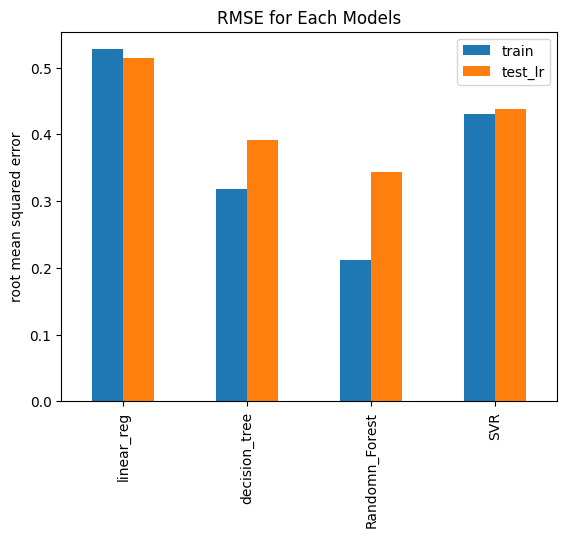

In [12]:
dict = {
    "linear_reg" : {"train": train_lr, "test_lr": test_lr},
    "decision_tree" : {"train": train_tr, "test_lr": test_tr},
    "Randomn_Forest" : {"train": train_rf, "test_lr": test_rf},
    "SVR" : {"train": train_sv, "test_lr": test_sv}
}

pd.DataFrame(dict).transpose().plot(kind="bar")
plt.ylabel("root mean squared error")
plt.title("RMSE for Each Models")

## OPTIMIZING THE MODELS

In [31]:
# ------- LINEAR REGRESSION -------
# Load and transform data
X_train, X_test, y_train, y_test = load_and_transform(train_dir)

# instantiate model
lr_model = LinearRegression()

# Full pipeline
model = build_full_pipeline(lr_model)

# cross validation score evaluation
val_score = -cross_val_score(
    model,
    X_train,
    y_train,
    scoring= "neg_root_mean_squared_error",
    cv= 10
)

# Statistic summary of cross_validation_score
pd.Series(val_score).describe()

count    10.000000
mean      0.528869
std       0.014623
min       0.508683
25%       0.518312
50%       0.525108
75%       0.543737
max       0.547211
dtype: float64

In [ ]:
# ------- RIDGE REGRESSION -------
# instantiate model
ridge = Ridge()

# full pipeline
model = build_full_pipeline(ridge)

# hyperparameter lists
params = {"model__alpha": [0.1, 1.0, 10.0, 100.0]}

grid_search = GridSearchCV(
    model,
    params,
    scoring = "neg_root_mean_squared_error",
    cv = 10
)
grid_search.fit(X_train, y_train)

# Dataframe of cv_result
cv_res = pd.DataFrame(grid_search.cv_results_)

# Best parameter
grid_search.best_params_

{'model__alpha': 1.0}

In [ ]:
cv_res

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__alpha,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,0.111104,0.026247,0.020557,0.005901,0.1,{'model__alpha': 0.1},-0.523494,-0.544562,-0.541259,-0.512293,-0.545702,-0.517244,-0.526723,-0.508683,-0.521520,-0.547213,-0.528869,0.013873,3
1,0.092190,0.017889,0.018221,0.003241,1.0,{'model__alpha': 1.0},-0.523503,-0.544542,-0.541273,-0.512279,-0.545681,-0.517253,-0.526716,-0.508682,-0.521511,-0.547227,-0.528867,0.013872,1
2,0.102630,0.020284,0.017843,0.005875,10.0,{'model__alpha': 10.0},-0.523596,-0.544370,-0.541416,-0.512153,-0.545494,-0.517354,-0.526665,-0.508712,-0.521541,-0.547372,-0.528867,0.013861,2
3,0.113834,0.019816,0.019362,0.005020,100.0,{'model__alpha': 100.0},-0.524502,-0.543879,-0.542874,-0.511810,-0.544782,-0.518798,-0.526776,-0.509815,-0.522962,-0.548797,-0.529499,0.013717,4


In [ ]:
# ------- LASSO REGRESSION -------
# instantiate model
lasso = Lasso()

# full pipeline
model = build_full_pipeline(lasso)

# hyperparameter lists
params = {"model__alpha": [0.1, 1.0, 10.0, 100.0]}

grid_search = GridSearchCV(
    model,
    params,
    scoring = "neg_root_mean_squared_error",
    cv = 10
)
grid_search.fit(X_train, y_train)

# Dataframe of cv_result
cv_res = pd.DataFrame(grid_search.cv_results_)

# Best parameter
grid_search.best_params_

{'model__alpha': 0.1}

In [ ]:
cv_res

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__alpha,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,0.085180,0.029459,0.014831,0.004494,0.1,{'model__alpha': 0.1},-0.587534,-0.607043,-0.629152,-0.578938,-0.617966,-0.605345,-0.592100,-0.601198,-0.594833,-0.625164,-0.603927,0.015554,1
1,0.059177,0.006976,0.007679,0.006697,1.0,{'model__alpha': 1.0},-0.871825,-0.880403,-0.924928,-0.854388,-0.897355,-0.900259,-0.884454,-0.888740,-0.872219,-0.901966,-0.887654,0.018726,2
2,0.050770,0.004836,0.013502,0.005105,10.0,{'model__alpha': 10.0},-0.871825,-0.880403,-0.924928,-0.854388,-0.897355,-0.900259,-0.884454,-0.888740,-0.872219,-0.901966,-0.887654,0.018726,2
3,0.060206,0.007385,0.010104,0.007746,100.0,{'model__alpha': 100.0},-0.871825,-0.880403,-0.924928,-0.854388,-0.897355,-0.900259,-0.884454,-0.888740,-0.872219,-0.901966,-0.887654,0.018726,2


In [ ]:
# ------- DECISION TREE REGRESSOR -------
# instantiate model
tree = DecisionTreeRegressor()

# full pipeline
model = build_full_pipeline(tree)

# hyperparameter lists
params = {
    "model__max_depth": [5, 10, 15, 20],
    "model__min_samples_leaf": [5, 10, 20, 30, 40, 50]
}

grid_search = GridSearchCV(
    model,
    params,
    scoring = 'neg_root_mean_squared_error',
    cv = 5
)
grid_search.fit(X_train, y_train)

# Dataframe of cv_result
cv_res = pd.DataFrame(grid_search.cv_results_)

# Best parameter
grid_search.best_params_

{'model__max_depth': 15, 'model__min_samples_leaf': 10}

In [ ]:
cv_res.sort_values(by="mean_test_score", ascending=False).head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__max_depth,param_model__min_samples_leaf,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
13,0.108617,0.007751,0.011024,0.006264,15,10,"{'model__max_depth': 15, 'model__min_samples_l...",-0.394936,-0.396128,-0.375909,-0.380184,-0.433106,-0.396053,0.020158,1
19,0.100187,0.004359,0.016110,0.005511,20,10,"{'model__max_depth': 20, 'model__min_samples_l...",-0.397991,-0.397247,-0.378635,-0.381636,-0.433767,-0.397855,0.019609,2
7,0.089089,0.004846,0.014926,0.001730,10,10,"{'model__max_depth': 10, 'model__min_samples_l...",-0.399830,-0.398625,-0.381763,-0.383477,-0.433827,-0.399504,0.018711,3
6,0.092463,0.007676,0.012487,0.006670,10,5,"{'model__max_depth': 10, 'model__min_samples_l...",-0.396470,-0.405359,-0.385873,-0.385536,-0.433089,-0.401266,0.017532,4
12,0.109509,0.007487,0.010992,0.007253,15,5,"{'model__max_depth': 15, 'model__min_samples_l...",-0.394943,-0.407215,-0.386343,-0.387414,-0.430913,-0.401366,0.016546,5


In [10]:
# ------- RANDOM FOREST REGRESSOR -------
# instantiate model
rf = RandomForestRegressor()

# full pipeline
model = build_full_pipeline(rf)

# hyperparameter lists
param_distribs = {
    "model__n_estimators": randint(low=100, high=400),
    "model__max_depth": randint(low=20, high=30),
    "model__min_samples_split": randint(low=5, high=10),
    "model__max_features": uniform(loc=0.6, scale=1)
}

# random search
rand_search = RandomizedSearchCV(
    estimator= model,
    param_distributions= param_distribs,
    n_iter= 10,
    scoring="neg_root_mean_squared_error",
    cv= 5,
    verbose=2,
    random_state=42,
)
rand_search.fit(X_train, y_train)

# Dataframe of cv_result
cv_res = pd.DataFrame(rand_search.cv_results_)

# Best parameter
best_param = rand_search.best_params_

# best_model 
best_model = rand_search.best_estimator_

best_param

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END model__max_depth=26, model__max_features=1.3965429868602328, model__min_samples_split=7, model__n_estimators=171; total time=   0.0s
[CV] END model__max_depth=26, model__max_features=1.3965429868602328, model__min_samples_split=7, model__n_estimators=171; total time=   0.0s
[CV] END model__max_depth=26, model__max_features=1.3965429868602328, model__min_samples_split=7, model__n_estimators=171; total time=   0.0s
[CV] END model__max_depth=26, model__max_features=1.3965429868602328, model__min_samples_split=7, model__n_estimators=171; total time=   0.0s
[CV] END model__max_depth=26, model__max_features=1.3965429868602328, model__min_samples_split=7, model__n_estimators=171; total time=   0.0s
[CV] END model__max_depth=24, model__max_features=0.7560186404424365, model__min_samples_split=7, model__n_estimators=314; total time=  37.0s
[CV] END model__max_depth=24, model__max_features=0.7560186404424365, model__min_sample

c:\Users\user\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
25 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\user\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\user\anaconda3\Lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\user\anaconda3\Lib\site-packages\sklearn\pipeline.py", line 662, in fit
    self._final_estimator.fit(Xt, 

{'model__max_depth': 29,
 'model__max_features': np.float64(0.6466656632136154),
 'model__min_samples_split': 8,
 'model__n_estimators': 370}

In [35]:
cv_res.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__max_depth,param_model__max_features,param_model__min_samples_split,param_model__n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.160995,0.047078,0.000000,0.00000,11,1.396543,12,288,"{'model__max_depth': 11, 'model__max_features'...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
1,39.421374,5.723344,0.784082,0.12656,25,0.756019,7,314,"{'model__max_depth': 25, 'model__max_features'...",-0.348419,-0.349926,-0.331718,-0.320704,-0.368082,-0.34377,0.016296,1
2,0.184704,0.044001,0.000000,0.00000,15,1.059249,9,199,"{'model__max_depth': 15, 'model__max_features'...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
3,0.128780,0.008105,0.000000,0.00000,12,1.308073,10,357,"{'model__max_depth': 12, 'model__max_features'...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
4,0.144126,0.048352,0.000000,0.00000,28,1.432443,10,291,"{'model__max_depth': 28, 'model__max_features'...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,4


In [16]:
# ----- SAVING BEST MODEL ------
# Extract best estimator
best_model = rand_search.best_estimator_

# save best model
joblib.dump(
    best_model,
    root_folder / "india_housing_price_model.pkl"
)

['c:\\Users\\user\\Desktop\\housing_prediction_DF_proj_1\\india_housing_price_model.pkl']

In [ ]:
# ------ GRIDSEARCH CV ---------
def run_gridsearch_model(X_train, y_train, model_instance, parameters):
    """
    About:
        Function that runs gridsearch cross validation to obtain best parameters
    Input:
        X_train,
        y_train,
        model_instance,
        parameters - (dict)
    output:
        grid_search,
        cv_result - (pd.DataFrame)
    """

    # full pipeline
    model = build_full_pipeline(model_instance)

    # grid search 
    grid_search = GridSearchCV(
        model_instance,
        parameters,
        scoring = 'neg_root_mean_squared_error',
        cv = 5
    )
    grid_search.fit(X_train, y_train)

    # Dataframe of cv_result
    cv_res = pd.DataFrame(grid_search.cv_results_)

    return grid_search, cv_res

In [ ]:
# ------- RANDOMIZED SEARCH CV ------

def run_randomize_search(model_instance, X_train, y_train, params_distribs, n_iter=10):
    """
    About:
        Function to perform Randomize search to obtain best model parameters
    Input:
        model_instance, eg LinearRegression()
        X_train - pd.DataFrame
        y_train - pd.Series
        params_distribs - dict
        n_iter - int
    output:
        rand_search,
        cv_result - pd.DataFrame
    """
    
    # full pipeline
    model = build_full_pipeline(model_instance)

    # random search
    rand_search = RandomizedSearchCV(
        estimator= model,
        param_distributions= param_distribs,
        n_iter= n_iter,
        scoring="neg_root_mean_squared_error",
        cv= 5,
        verbose=2,
        random_state=42,
    )
    rand_search.fit(X_train, y_train)

    # Dataframe of cv_result
    cv_res = pd.DataFrame(rand_search.cv_results_)

    # Best parameter
    best_param = rand_search.best_params_

    # best_model 
    best_model = rand_search.best_estimator_

    return rand_search, cv_res

## Communicating Result

In [23]:
# ------ LOAD SAVED MODEL -------
model = joblib.load(root_folder/"india_housing_price_model.pkl")

model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('tge',
                                                  TargetEncoder(cols=['CITY'],
                                                                smoothing=0.1),
                                                  ['CITY']),
                                                 ('num', StandardScaler(),
                                                  ['UNDER_CONSTRUCTION', 'RERA',
                                                   'RESALE', 'BHK_NO._CAPPED',
                                                   'LATITUDE_CLIPPED',
                                                   'LONGITUDE_CLIPPED',
                                                   'SQFT_PER_BHK_LOG']),
                                                 ('ohe',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['POSTED_BY', 'BHK_OR_RK'])],
                                   verbose_feature_names_out=False)),
                ('model',
                 RandomForestRegressor(max_depth=29,
                                       max_features=np.float64(0.6466656632136154),
                                       min_samples_split=8,
                                       n_estimators=370))])

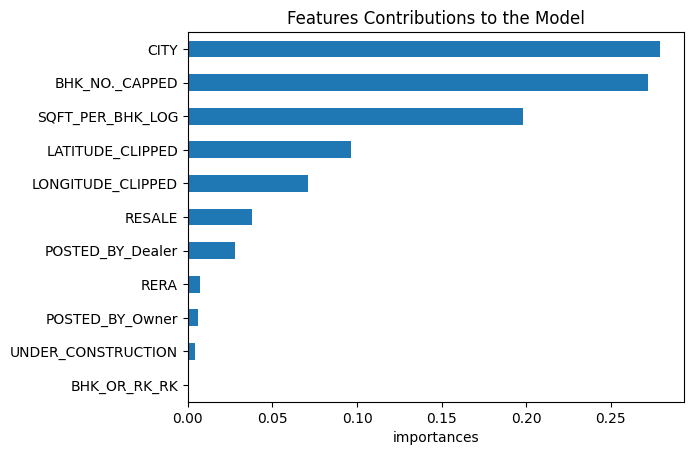

In [28]:
# feature importance
features_imp = model["model"].feature_importances_

# feature_names
feature_names = model["preprocessor"].get_feature_names_out()

# create pandas Series
pd.Series(features_imp, index=feature_names).sort_values().plot(kind="barh")
plt.title("Features Contributions to the Model")
plt.xlabel("importances")
plt.show()